***EXP-10***
# *23A91A0459*
***S.Nikhil Prince***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Required Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, roc_curve, roc_auc_score

Reading the heart disease dataset

In [ ]:
# Load dataset
data = pd.read_csv("/content/heart-1.csv")

Separate Features and Target

In [ ]:
# X contains input features
X = data.drop("target", axis=1)

# y contains output class
y = data["target"]

Train–Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Bagging Model

In [ ]:
# Create Bagging model
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # Base estimator
    n_estimators=50,                     # Number of trees
    random_state=42
)

# Train the Bagging model
bagging.fit(X_train, y_train)

# Predict on test data
y_pred_bag = bagging.predict(X_test)

# Display results

print("\n Confusion Matrix: \n", confusion_matrix(y_test, y_pred_bag))
print("\n Accuracy:", accuracy_score(y_test, y_pred_bag)*100)
print("\n Bagging Classification Report: \n", classification_report(y_test, y_pred_bag))


 Confusion Matrix: 
 [[102   0]
 [  3 100]]

 Accuracy: 98.53658536585365

 Bagging Classification Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



AdaBoost Model

In [ ]:
# Create AdaBoost model with shallow decision tree
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,                   # Number of weak learners
    learning_rate=0.5,                  # Contribution of each learner
    random_state=42
)


# Train AdaBoost model
adaboost.fit(X_train, y_train)

# Predict on test data
y_pred_ada = adaboost.predict(X_test)

# Display results
print("\n Confusion Matrix: \n", confusion_matrix(y_test, y_pred_ada))
print("\n Accuracy:", accuracy_score(y_test, y_pred_ada)*100)
print("\n Bagging Classification Report: \n", classification_report(y_test, y_pred_ada))



 Confusion Matrix: 
 [[78 24]
 [12 91]]

 Accuracy: 82.4390243902439

 Bagging Classification Report: 
               precision    recall  f1-score   support

           0       0.87      0.76      0.81       102
           1       0.79      0.88      0.83       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



Random Forest Model

In [ ]:
# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,                  # Number of trees
    max_depth=10,                       # Maximum depth of each tree
    min_samples_split=5,               # Minimum samples to split a node
    random_state=42
)

# Train Random Forest model
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Display results
print("\n Confusion Matrix: \n", confusion_matrix(y_test, y_pred_rf))
print("\n Accuracy:", accuracy_score(y_test, y_pred_rf)*100)
print("\n Bagging Classification Report: \n", classification_report(y_test, y_pred_rf))



 Confusion Matrix: 
 [[102   0]
 [  3 100]]

 Accuracy: 98.53658536585365

 Bagging Classification Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

Plotting the Graph

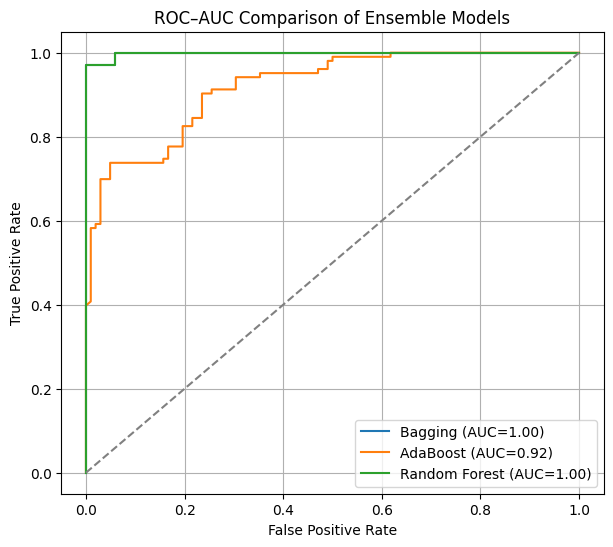

In [ ]:
plt.figure(figsize=(7,6))

# Bagging
y_prob_bag = bagging.predict_proba(X_test)[:,1]
fpr_bag, tpr_bag, _ = roc_curve(y_test, y_prob_bag)
auc_bag = roc_auc_score(y_test, y_prob_bag)
plt.plot(fpr_bag, tpr_bag, label=f"Bagging (AUC={auc_bag:.2f})")

# AdaBoost
y_prob_ada = adaboost.predict_proba(X_test)[:,1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
auc_ada = roc_auc_score(y_test, y_prob_ada)
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC={auc_ada:.2f})")

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.2f})")

# Random classifier
plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Comparison of Ensemble Models")
plt.legend()
plt.grid(True)
plt.show()
